In [1]:
import hdbscan
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import matplotlib.patches as mpatches
from shapely.geometry import MultiPoint
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings
from shapely.geometry import MultiPoint
from esda.getisord import G_Local
from libpysal.weights import Queen

# Set global display format to show up to 6 decimal places
# pd.options.display.float_format = '{:.6f}'.format

# 1. Load and Visualize Data

## Read waste

In [2]:
df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Correct_SVI.csv")
df = df[(df['img_dir'] != 'ZWL/') & (df['img_dir'] != 'Faith/')]
df = df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')
# df

# Ensure your df has 'lat' and 'lon' columns
df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

# Convert to a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
73,1Xyfr0j4E3Gx6_Coadexow_180,2018,2,NaN,NaN,-1.282457,36.751317,1Xyfr0j4E3Gx6_Coadexow,Google/1/X/,True,[0.4008658230304718],"[[298.3153076171875, 184.95751953125, 400.0, 2...",1,yes,Y,Y,POINT (36.75132 -1.28246)
74,nTRlyH7aG8CmTfOI1_akgw_0,2018,3,NaN,NaN,-1.279155,36.719541,nTRlyH7aG8CmTfOI1_akgw,Google/n/T/,True,"[0.5433366894721985, 0.3535045087337494]","[[50.18629455566406, 221.9884033203125, 188.91...",2,yes,Y,N,POINT (36.71954 -1.27915)
75,uc2yRcVOf6bCSyBKfnm0Sw_90,2018,2,NaN,NaN,-1.283062,36.751316,uc2yRcVOf6bCSyBKfnm0Sw,Google/u/c/,True,"[0.3149861693382263, 0.2503598630428314]","[[0.0, 248.11912536621094, 191.11526489257812,...",2,yes,Y,Y,POINT (36.75132 -1.28306)
76,y_-_BCz3RPfZPFkLoqlA7Q_0,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.3682653307914734],"[[185.56979370117188, 191.65072631835938, 309....",1,yes,Y,Y,POINT (36.74569 -1.28506)
77,y_-_BCz3RPfZPFkLoqlA7Q_90,2018,2,NaN,NaN,-1.285056,36.745694,y_-_BCz3RPfZPFkLoqlA7Q,Google/y/_/,True,[0.27535533905029297],"[[71.40460968017578, 221.17556762695312, 324.6...",1,yes,Y,Y,POINT (36.74569 -1.28506)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3965,K2bDOcQT-fC73J3sTszcJw_0,2021,8,NaN,NaN,-1.314196,36.889760,K2bDOcQT-fC73J3sTszcJw,Google/K/2/,True,[0.5377181172370911],"[[322.23724365234375, 0.0, 399.8905944824219, ...",1,yes,Y,Y,POINT (36.88976 -1.3142)
3966,A2MMbVUET-qhK8hNcteVBw_180,2018,2,NaN,NaN,-1.276726,36.919951,A2MMbVUET-qhK8hNcteVBw,Google/A/2/,True,[0.8420240879058838],"[[2.8917694091796875, 153.89686584472656, 383....",1,yes,Y,N,POINT (36.91995 -1.27673)
3967,zVDYat_guuNnsZ9DemVKwA_180,2018,2,NaN,NaN,-1.276957,36.919431,zVDYat_guuNnsZ9DemVKwA,Google/z/V/,True,[0.6924970149993896],"[[0.0, 183.14369201660156, 185.0641632080078, ...",1,yes,Y,Y,POINT (36.91943 -1.27696)
3968,u_Zx9slVChF217zkkuGJnw_0,2021,8,NaN,NaN,-1.313337,36.872663,u_Zx9slVChF217zkkuGJnw,Google/u/_/,True,[0.40619784593582153],"[[126.26983642578125, 238.47946166992188, 328....",1,yes,Y,N,POINT (36.87266 -1.31334)


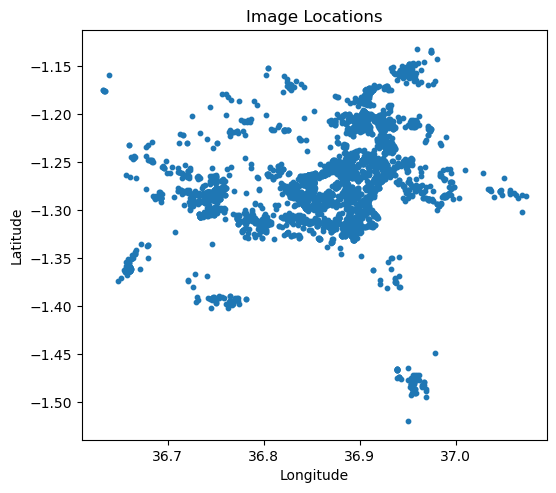

In [3]:
# Quick scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(ax=ax, markersize=10)

plt.title("Image Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Load Nairobi boundary

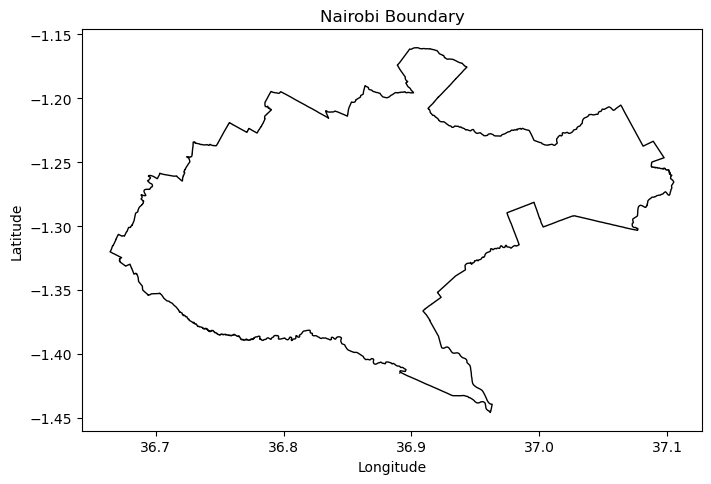

In [4]:
# boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/BaseMap/AoI_BigBoundary.gpkg")
boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Shp/NariobiShp/Shp_from_Constituency/Nairobi_shp_C.shp")

fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

plt.title("Nairobi Boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Load Slum shapefile

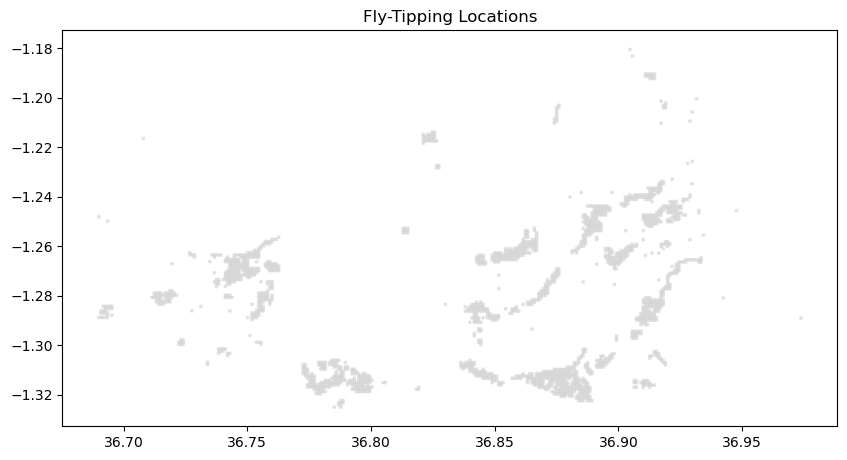

In [5]:
# Plot the points
slums_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")

fig, ax = plt.subplots(figsize=(10, 8))
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Locations")
plt.show()

## Load Road & All SVI

In [6]:
Rd = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/OSM_NAI_AOI.gpkg")
Rd

,osm_id,name,ref,type,oneway,bridge,maxspeed,lenght,node_count,geometry
0,4685092,None,B10E,secondary,1,0,NaN,1183.19,21.0,"MULTILINESTRING ((36.91442 -1.34465, 36.91427 ..."
1,4716859,None,None,tertiary,1,0,NaN,17.04,1.0,"MULTILINESTRING ((36.77944 -1.30009, 36.77943 ..."
2,4716860,State House Avenue,D2001,secondary,0,0,NaN,902.79,28.0,"MULTILINESTRING ((36.80434 -1.28648, 36.80449 ..."
3,4716861,Processional Way,None,tertiary,0,0,NaN,138.80,7.0,"MULTILINESTRING ((36.81358 -1.28721, 36.81397 ..."
4,4716862,Kenyatta Avenue,UCB7-Nairobi,secondary,1,0,NaN,166.32,9.0,"MULTILINESTRING ((36.81026 -1.2895, 36.81034 -..."
...,...,...,...,...,...,...,...,...,...,...
65175,1219966300,Ngong Road,D2001,secondary,1,0,NaN,109.91,6.0,"MULTILINESTRING ((36.81257 -1.28979, 36.8124 -..."
65176,1220409349,None,None,residential,0,0,NaN,49.04,1.0,"MULTILINESTRING ((36.90215 -1.27911, 36.90255 ..."
65177,1220409350,None,None,residential,0,0,NaN,75.59,4.0,"MULTILINESTRING ((36.89964 -1.2772, 36.8999 -1..."
65178,1220409351,None,None,residential,0,0,NaN,43.14,1.0,"MULTILINESTRING ((36.90245 -1.2787, 36.9028 -1..."


In [7]:
AllSVI_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Combined_SVI.csv", low_memory=False)
AllSVI_df = AllSVI_df[(AllSVI_df['img_dir'] != 'ZWL/') & (AllSVI_df['img_dir'] != 'Faith/')]
AllSVI_df = AllSVI_df.drop(columns=['year', 'month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
AllSVI_df = AllSVI_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')

# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
AllSVI_df['geometry'] = AllSVI_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
AllSVI = gpd.GeoDataFrame(AllSVI_df, geometry='geometry', crs="EPSG:4326")
AllSVI

,img_name,lat,lon,panoid,img_dir,Domestic,geometry
817,KdbXvhlAf5Sqjw-hwBb_Ww_0,-1.240368,36.928039,KdbXvhlAf5Sqjw-hwBb_Ww,Google/K/d/,N,POINT (36.92804 -1.24037)
818,1Xyfr0j4E3Gx6_Coadexow_180,-1.282457,36.751317,1Xyfr0j4E3Gx6_Coadexow,Google/1/X/,Y,POINT (36.75132 -1.28246)
819,AgROMWzI6TjbZRpV6iKJDg_270,-1.284253,36.902957,AgROMWzI6TjbZRpV6iKJDg,Google/A/g/,N,POINT (36.90296 -1.28425)
820,AgROMWzI6TjbZRpV6iKJDg_180,-1.284253,36.902957,AgROMWzI6TjbZRpV6iKJDg,Google/A/g/,N,POINT (36.90296 -1.28425)
821,nTRlyH7aG8CmTfOI1_akgw_0,-1.279155,36.719541,nTRlyH7aG8CmTfOI1_akgw,Google/n/T/,Y,POINT (36.71954 -1.27915)
...,...,...,...,...,...,...,...
454176,P8R4aL4MRoJ3I1BAqd9log_180,-1.243328,36.658198,P8R4aL4MRoJ3I1BAqd9log,Google/P/8/,NaN,POINT (36.6582 -1.24333)
454177,P8R4aL4MRoJ3I1BAqd9log_270,-1.243328,36.658198,P8R4aL4MRoJ3I1BAqd9log,Google/P/8/,NaN,POINT (36.6582 -1.24333)
454178,Cj_q1UE8aOoi93oRvPOrKA_0,-1.223843,36.779281,Cj_q1UE8aOoi93oRvPOrKA,Google/C/j/,NaN,POINT (36.77928 -1.22384)
454179,Cj_q1UE8aOoi93oRvPOrKA_90,-1.223843,36.779281,Cj_q1UE8aOoi93oRvPOrKA,Google/C/j/,NaN,POINT (36.77928 -1.22384)


In [8]:
print(AllSVI.crs)

EPSG:4326


## Clip to Nairobi

In [9]:
# Clip points inside the boundary
clipped_gdf = gpd.clip(gdf, boundary)
slums_gdf = gpd.clip(slums_gdf, boundary)
Rd_gdf = gpd.clip(Rd, boundary)
AllSVI_gdf = gpd.clip(AllSVI, boundary)

# Display result
clipped_gdf
# 3897 -> 3236

slums_gdf
# 1998 -> 1988

Rd_gdf
# 65180 -> 45207

AllSVI_gdf
# 453364 -> 306420

,img_name,lat,lon,panoid,img_dir,Domestic,geometry
308838,04f04FETh1-7-HxXPMM1MA_90,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (36.9349 -1.42079)
308839,04f04FETh1-7-HxXPMM1MA_180,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (36.9349 -1.42079)
308837,04f04FETh1-7-HxXPMM1MA_0,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (36.9349 -1.42079)
308840,04f04FETh1-7-HxXPMM1MA_270,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (36.9349 -1.42079)
308844,YPnfMUSUF59IfX9y7tLlFg_270,-1.420173,36.934085,YPnfMUSUF59IfX9y7tLlFg,Google/Y/P/,NaN,POINT (36.93409 -1.42017)
...,...,...,...,...,...,...,...
189177,nQVAGJNiiyTCTG_SyQwYpQ_0,-1.166406,36.919726,nQVAGJNiiyTCTG_SyQwYpQ,Google/n/Q/,NaN,POINT (36.91973 -1.16641)
131509,iKn-D0JVGk6DU8_RnwXTTw_270,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (36.91978 -1.16628)
132105,iKn-D0JVGk6DU8_RnwXTTw_0,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (36.91978 -1.16628)
132107,iKn-D0JVGk6DU8_RnwXTTw_90,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (36.91978 -1.16628)


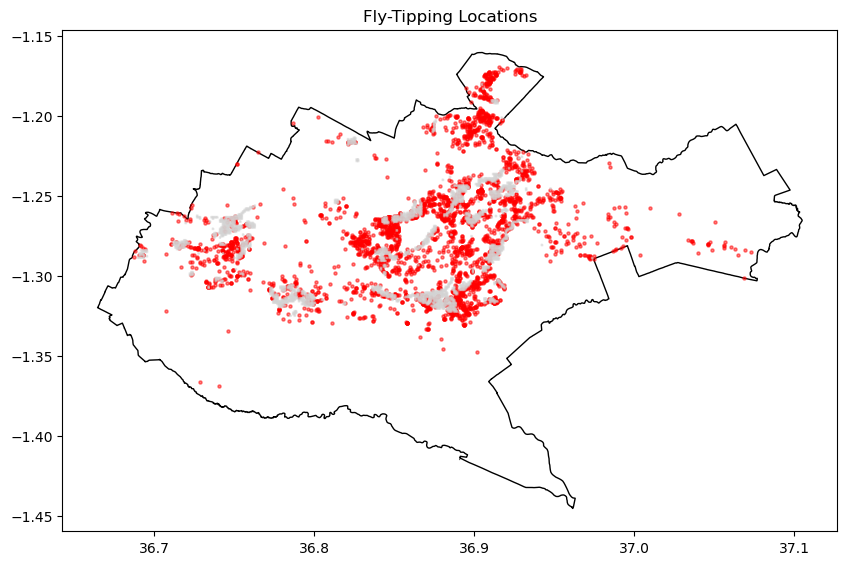

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
clipped_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.5)
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Locations")
plt.show()

In [11]:
slums_gdf.shape[0]

1988

In [12]:
boundary.shape[0]

1

In [13]:
print(clipped_gdf.crs)
print(boundary.crs)

EPSG:4326
EPSG:4326


In [14]:
# Reproject to UTM Zone 37S (EPSG:32737)
projected_crs = "EPSG:32737"  
boundary_projected = boundary.to_crs(projected_crs)
clipped_gdf_projected = clipped_gdf.to_crs(projected_crs)
slums_gdf_projected = slums_gdf.to_crs(projected_crs)
Rd_gdf_projected = Rd_gdf.to_crs(projected_crs)
AllSVI_gdf_projected = AllSVI_gdf.to_crs(projected_crs)

print(clipped_gdf_projected.crs)
print(boundary_projected.crs)
print(slums_gdf_projected.crs)
print(Rd_gdf_projected.crs)
print(AllSVI_gdf_projected.crs)

EPSG:32737
EPSG:32737
EPSG:32737
EPSG:32737
EPSG:32737


In [15]:
boundary_area_m2 = boundary_projected.geometry.area.sum()
boundary_area_km2 = boundary_area_m2 / 1e6

print("Boundary area (km²):", boundary_area_km2)

Boundary area (km²): 695.1003305326267


In [16]:
slums_area_m2 = slums_gdf_projected.geometry.area.sum()
slums_area_km2 = slums_area_m2 / 1e6

print("Slums total area (km²):", slums_area_km2)

Slums total area (km²): 19.861085766939148


In [17]:
percentage = (slums_area_m2 / boundary_area_m2) * 100

print("Slum coverage (%):", percentage)

Slum coverage (%): 2.857297701429723


In [18]:
clipped_gdf_projected

,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry
2130,fLCK5eRBG99LGbCuDSBlgQ_270,2018,2,NaN,NaN,-1.301553,37.068682,fLCK5eRBG99LGbCuDSBlgQ,Google/f/L/,True,[0.3712886571884155],"[[78.21759796142578, 205.15240478515625, 140.3...",1,yes,Y,Y,POINT (285106.759 9856056.789)
134,KQqt-j2iDREGChLobmRc6Q_270,2018,2,NaN,NaN,-1.267932,36.926420,KQqt-j2iDREGChLobmRc6Q,Google/K/Q/,True,[0.3236929476261139],"[[326.3240051269531, 168.91143798828125, 399.1...",1,yes,Y,N,POINT (269267.947 9859762.717)
2550,J8QJYKLvKqLF8w4OoKfTuQ_270,2021,7,NaN,NaN,-1.290786,36.947096,J8QJYKLvKqLF8w4OoKfTuQ,Google/J/8/,True,[0.529024600982666],"[[322.16461181640625, 159.08607482910156, 400....",1,yes,Y,Y,POINT (271571.645 9857236.884)
758,MH78KhYMGe2dun78nwlT5w_270,2021,7,NaN,NaN,-1.287349,36.944651,MH78KhYMGe2dun78nwlT5w,Google/M/H/,True,[0.4912583529949188],"[[6.17279052734375, 158.3504638671875, 395.884...",1,yes,Y,Y,POINT (271299.152 9857616.775)
759,NWm1T8TxTt-Bmzi4rM72Nw_180,2021,8,NaN,NaN,-1.286800,36.950329,NWm1T8TxTt-Bmzi4rM72Nw,Google/N/W/,True,[0.34495213627815247],"[[306.3589172363281, 196.9697265625, 400.0, 25...",1,yes,Y,N,POINT (271931.178 9857678.067)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2599,9PwIBuolh2emZsCd1sdLmg_270,2018,2,NaN,NaN,-1.172356,36.929183,9PwIBuolh2emZsCd1sdLmg,Google/9/P/,True,[0.4162435531616211],"[[255.76260375976562, 184.0593719482422, 366.9...",1,yes,Y,Y,POINT (269567.339 9870334.003)
2933,Dqk-gB7bOQfUNTK60DoAHA_90,2018,2,NaN,NaN,-1.171336,36.926384,Dqk-gB7bOQfUNTK60DoAHA,Google/D/q/,True,"[0.47815805673599243, 0.2923596501350403]","[[181.90997314453125, 178.96670532226562, 374....",2,yes,Y,N,POINT (269255.722 9870446.639)
3306,2RWOhtBYT4bIPRQN7N5e7Q_90,2018,2,NaN,NaN,-1.170963,36.926969,2RWOhtBYT4bIPRQN7N5e7Q,Google/2/R/,True,[0.30108121037483215],"[[279.8357849121094, 244.15794372558594, 399.0...",1,yes,Y,N,POINT (269320.781 9870487.958)
3305,M2dwa7vqByWyEPpVI2I2kw_0,2018,2,NaN,NaN,-1.170780,36.928983,M2dwa7vqByWyEPpVI2I2kw,Google/M/2/,True,[0.6980969309806824],"[[95.78693389892578, 201.8352508544922, 397.75...",1,yes,Y,N,POINT (269544.958 9870508.318)


## Check the number of slums

In [20]:
# Step 1: explode (if multipolygons exist)
slums = slums_gdf.explode(index_parts=False)

In [21]:
# Step 2: build spatial clusters (touching polygons)
import geopandas as gpd
from shapely.ops import unary_union
import networkx as nx

In [22]:
# Step 3: create adjacency graph
slums = slums.reset_index(drop=True)

G = nx.Graph()

for idx, geom in slums.geometry.items():
    G.add_node(idx)
    neighbors = slums[slums.geometry.touches(geom)].index
    for n in neighbors:
        G.add_edge(idx, n)

In [23]:
# Step 4: extract connected components
clusters = list(nx.connected_components(G))

In [24]:
# Step 5: dissolve each cluster into one polygon
cluster_geoms = []

for cluster in clusters:
    merged = unary_union(slums.loc[list(cluster)].geometry)
    cluster_geoms.append(merged)

slum_polygons = gpd.GeoDataFrame(geometry=cluster_geoms, crs=slums.crs)

In [25]:
slum_polygons.shape[0]

101

In [31]:
slum_polygons_projected = slum_polygons.to_crs("EPSG:32737")
slum_polygons_projected["area_km2"] = slum_polygons_projected.geometry.area / 1e6
total_slum_area_km2 = slum_polygons_projected["area_km2"].sum()
print(total_slum_area_km2)

19.86108576693914


In [33]:
slum_polygons_projected["area_km2"].describe()

count    101.000000
mean       0.196644
std        0.451965
min        0.000283
25%        0.010000
50%        0.020000
75%        0.120000
max        2.810000
Name: area_km2, dtype: float64

## percent of SVI / road in Nairobi

In [19]:
# AllSVI_gdf_projected
# clipped_gdf_projected
# Rd_gdf_projected

,img_name,lat,lon,panoid,img_dir,Domestic,geometry
308838,04f04FETh1-7-HxXPMM1MA_90,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (270226.322 9842856.531)
308839,04f04FETh1-7-HxXPMM1MA_180,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (270226.322 9842856.531)
308837,04f04FETh1-7-HxXPMM1MA_0,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (270226.322 9842856.531)
308840,04f04FETh1-7-HxXPMM1MA_270,-1.420794,36.934901,04f04FETh1-7-HxXPMM1MA,Google/0/4/,NaN,POINT (270226.322 9842856.531)
308844,YPnfMUSUF59IfX9y7tLlFg_270,-1.420173,36.934085,YPnfMUSUF59IfX9y7tLlFg,Google/Y/P/,NaN,POINT (270135.47 9842925.134)
...,...,...,...,...,...,...,...
189177,nQVAGJNiiyTCTG_SyQwYpQ_0,-1.166406,36.919726,nQVAGJNiiyTCTG_SyQwYpQ,Google/n/Q/,NaN,POINT (268514.106 9870991.378)
131509,iKn-D0JVGk6DU8_RnwXTTw_270,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (268519.931 9871005.452)
132105,iKn-D0JVGk6DU8_RnwXTTw_0,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (268519.931 9871005.452)
132107,iKn-D0JVGk6DU8_RnwXTTw_90,-1.166278,36.919779,iKn-D0JVGk6DU8_RnwXTTw,Google/i/K/,NaN,POINT (268519.931 9871005.452)


In [22]:
print(clipped_gdf_projected.crs)
print(AllSVI_gdf_projected.crs)
print(Rd_gdf_projected.crs)

EPSG:32737
EPSG:32737
EPSG:32737


In [29]:
from shapely.ops import unary_union

# 50 m buffers around points
points_buffer = clipped_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

# Merge all buffers into one geometry
buffer_union = unary_union(points_buffer.geometry)

# Intersect roads with buffer area
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)

# Remove empty geometries
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty].copy()

# Compute lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
uncovered_pct = 100 - coverage_pct

print(f"Road coverage within 50m: {coverage_pct:.2f}%")
print(f"Road not covered within 50m: {uncovered_pct:.2f}%")

Road coverage within 50m: 6.08%
Road not covered within 50m: 93.92%


In [30]:
from shapely.ops import unary_union

# 50 m buffers around AllSVI points
points_buffer = AllSVI_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

# Merge all buffers into one geometry
buffer_union = unary_union(points_buffer.geometry)

# Intersect roads with buffer area
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)

# Remove empty geometries
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty].copy()

# Compute lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
uncovered_pct = 100 - coverage_pct

print(f"AllSVI road coverage within 50m: {coverage_pct:.2f}%")
print(f"AllSVI road not covered within 50m: {uncovered_pct:.2f}%")

AllSVI road coverage within 50m: 60.00%
AllSVI road not covered within 50m: 40.00%


In [ ]:
import matplotlib.pyplot as plt

# Covered road portions
covered_roads = Rd_gdf_projected.copy()
covered_roads["geometry"] = covered_roads.geometry.intersection(buffer_union)
covered_roads = covered_roads[~covered_roads.is_empty].copy()

# Uncovered road portions
uncovered_roads = Rd_gdf_projected.copy()
uncovered_roads["geometry"] = uncovered_roads.geometry.difference(buffer_union)
uncovered_roads = uncovered_roads[~uncovered_roads.is_empty].copy()

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Covered roads
covered_roads.plot(
    ax=ax,
    color="lightblue",
    linewidth=0.7,
    label="Covered within 50m"
)

# Uncovered roads
uncovered_roads.plot(
    ax=ax,
    color="red",
    linewidth=0.7,
    label="Not covered"
)

ax.set_title("Street View Road Coverage (50m Buffer)", fontsize=16)
ax.legend()
ax.set_axis_off()

plt.show()

In [23]:
# import geopandas as gpd

# Make sure everything is in the same projected CRS in meters
# (you already seem to have projected data)
roads = Rd_gdf_projected.copy()
all_pts = AllSVI_gdf_projected.copy()
clip_pts = clipped_gdf_projected.copy()

# Keep only valid geometries
roads = roads[roads.geometry.notna() & ~roads.geometry.is_empty].copy()
all_pts = all_pts[all_pts.geometry.notna() & ~all_pts.geometry.is_empty].copy()
clip_pts = clip_pts[clip_pts.geometry.notna() & ~clip_pts.geometry.is_empty].copy()

# Give roads a stable id
roads = roads.reset_index(drop=False).rename(columns={"index": "road_idx"})
roads["road_length_m"] = roads.geometry.length

total_road_length = roads["road_length_m"].sum()
print("Total road length (m):", total_road_length)

Total road length (m): 7572823.028024608


In [26]:
buf25 = all_pts.copy()
buf25["geometry"] = buf25.geometry.buffer(25)

# Join roads to buffered points
join25 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf25[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_25 = join25["road_idx"].drop_duplicates()

covered_length_25 = roads.loc[roads["road_idx"].isin(covered_road_idx_25), "road_length_m"].sum()
uncovered_length_25 = total_road_length - covered_length_25

print("AllSVI 25 m covered length (m):", covered_length_25)
print("AllSVI 25 m uncovered length (m):", uncovered_length_25)
print("AllSVI 25 m covered %:", 100 * covered_length_25 / total_road_length)
print("AllSVI 25 m uncovered %:", 100 * uncovered_length_25 / total_road_length)


# AllSVI 25 m covered length (m): 5660935.293627018
# AllSVI 25 m uncovered length (m): 1911887.7343975902
# AllSVI 25 m covered %: 74.7533023375523
# AllSVI 25 m uncovered %: 25.246697662447705

# AllSVI 50 m covered length (m): 6079820.17973002
# AllSVI 50 m uncovered length (m): 1493002.8482945878
# AllSVI 50 m covered %: 80.28472548784701
# AllSVI 50 m uncovered %: 19.715274512152988

AllSVI 25 m covered length (m): 6079820.17973002
AllSVI 25 m uncovered length (m): 1493002.8482945878
AllSVI 25 m covered %: 80.28472548784701
AllSVI 25 m uncovered %: 19.715274512152988


In [27]:
buf25 = clip_pts.copy()
buf25["geometry"] = buf25.geometry.buffer(25)

join25 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf25[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_25 = join25["road_idx"].drop_duplicates()

covered_length_25 = roads.loc[roads["road_idx"].isin(covered_road_idx_25), "road_length_m"].sum()
uncovered_length_25 = total_road_length - covered_length_25

print("clipped 25 m covered length (m):", covered_length_25)
print("clipped 25 m uncovered length (m):", uncovered_length_25)
print("clipped 25 m covered %:", 100 * covered_length_25 / total_road_length)
print("clipped 25 m uncovered %:", 100 * uncovered_length_25 / total_road_length)

# clipped 25 m covered length (m): 1139996.0727032833
# clipped 25 m uncovered length (m): 6432826.955321325
# clipped 25 m covered %: 15.053779396197701
# clipped 25 m uncovered %: 84.9462206038023

clipped 25 m covered length (m): 1139996.0727032833
clipped 25 m uncovered length (m): 6432826.955321325
clipped 25 m covered %: 15.053779396197701
clipped 25 m uncovered %: 84.9462206038023


In [28]:
buf50 = clip_pts.copy()
buf50["geometry"] = buf50.geometry.buffer(50)

join50 = gpd.sjoin(
    roads[["road_idx", "road_length_m", "geometry"]],
    buf50[["geometry"]],
    how="inner",
    predicate="intersects"
)

covered_road_idx_50 = join50["road_idx"].drop_duplicates()

covered_length_50 = roads.loc[roads["road_idx"].isin(covered_road_idx_50), "road_length_m"].sum()
uncovered_length_50 = total_road_length - covered_length_50

print("clipped 50 m covered length (m):", covered_length_50)
print("clipped 50 m uncovered length (m):", uncovered_length_50)
print("clipped 50 m covered %:", 100 * covered_length_50 / total_road_length)
print("clipped 50 m uncovered %:", 100 * uncovered_length_50 / total_road_length)

clipped 50 m covered length (m): 1590850.8045323242
clipped 50 m uncovered length (m): 5981972.223492284
clipped 50 m covered %: 21.007368040228744
clipped 50 m uncovered %: 78.99263195977126


In [48]:
# Create 50m buffers around points
points_buffer = clipped_gdf_projected.copy()
points_buffer["geometry"] = points_buffer.geometry.buffer(50)

In [49]:
# Merge all buffers into one geometry (faster + cleaner)
from shapely.ops import unary_union

buffer_union = unary_union(points_buffer.geometry)

In [51]:
# Clip roads by buffer area (intersection)
roads_in_buffer = Rd_gdf_projected.copy()
roads_in_buffer["geometry"] = roads_in_buffer.geometry.intersection(buffer_union)
roads_in_buffer = roads_in_buffer[~roads_in_buffer.is_empty]
roads_in_buffer

,osm_id,name,ref,type,oneway,bridge,maxspeed,lenght,node_count,geometry
28190,674937599,None,None,residential,0,0,NaN,225.55,10.0,"LINESTRING (272399.372 9857841.082, 272382.203..."
57648,926964705,None,None,residential,0,0,NaN,50.57,1.0,"LINESTRING (272383.399 9857791.356, 272416.959..."
60639,1051249816,None,None,service,0,0,NaN,30.13,1.0,"LINESTRING (272425.853 9857801.475, 272439.546..."
52136,918138229,None,None,service,0,0,NaN,41.60,1.0,"LINESTRING (272403.028 9857835.367, 272438.543..."
57649,926964706,None,None,residential,0,0,NaN,56.08,3.0,"LINESTRING (272349.006 9857846.018, 272357.207..."
...,...,...,...,...,...,...,...,...,...,...
59006,1022785548,None,None,service,0,0,NaN,22.53,1.0,"LINESTRING (269585.135 9870351.173, 269598.908..."
34249,678565719,None,None,residential,0,0,NaN,154.77,25.0,"LINESTRING (269273.898 9870463.725, 269281.374..."
34248,678565718,None,None,residential,0,0,NaN,52.95,8.0,"LINESTRING (269296.477 9870417.756, 269294.983..."
34247,678565717,None,None,residential,0,0,NaN,108.96,16.0,"LINESTRING (269564.898 9870498.559, 269562.364..."


In [52]:
# Compute road lengths
total_length = Rd_gdf_projected.geometry.length.sum()
covered_length = roads_in_buffer.geometry.length.sum()
coverage_pct = (covered_length / total_length) * 100
print(f"Road coverage within 50m: {coverage_pct:.2f}%")

Road coverage within 50m: 6.08%


In [ ]:
# -----------------------
# PLOT (important fix here)
# -----------------------
fig, ax = plt.subplots(figsize=(10, 10))

Rd_gdf_projected.plot(ax=ax, color="lightgrey", linewidth=0.8, label="Road network")
roads_covered.plot(ax=ax, color="red", linewidth=1.5, label="Covered roads")
clipped_gdf_projected.plot(ax=ax, color="blue", markersize=5, label="Sampling points")

gpd.GeoSeries(buffer_union).boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("50m Sampling Coverage of Road Network")
ax.set_axis_off()

ax.legend()

plt.tight_layout()
plt.show()

# 2. Kernel Density Estimation (KDE)
KDE provides a heatmap showing density variations, helping identify hotspots.


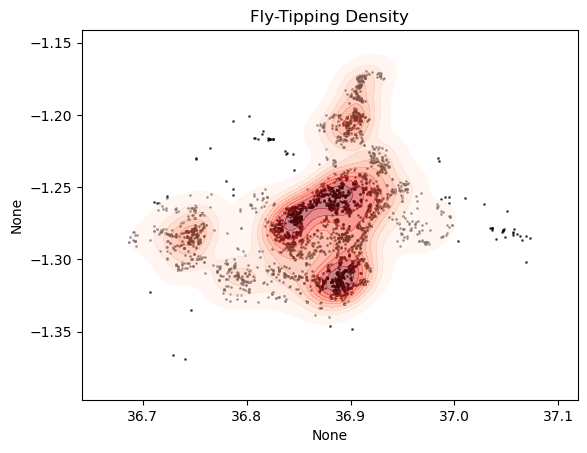

In [10]:
# Extract latitude & longitude
x = clipped_gdf.geometry.x
y = clipped_gdf.geometry.y

# Create KDE plot
plt.scatter(x, y, s=1, c='black', alpha=0.6)  # Overlay points
sns.kdeplot(x=x, y=y, cmap="Reds", fill=True, alpha=0.5)
plt.title("Fly-Tipping Density")
plt.show()

# 3. Nearest Neighbor Analysis
To check if fly-tipping points cluster more than random, compare their observed mean nearest-neighbor distance with an expected distance under complete spatial randomness (CSR).

pointpats package didn't work 

## 3.1 Load the Study Area and Compute Its Area

In [11]:
# Compute the area in square meters
study_area = boundary_projected.geometry.area.sum() 

print(f"Total study area: {study_area} square meters")

Total study area: 695100330.5326266 square meters


## 3.2 Compute Expected Mean NN Distance under CSR

In [12]:
coords = np.vstack([clipped_gdf_projected.geometry.x.values,
                    clipped_gdf_projected.geometry.y.values]).T

# Fit Nearest Neighbors Model
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(coords)

# Find nearest distances
distances, _ = nbrs.kneighbors(coords)

# Compute mean nearest neighbor distance (excluding self-distance)
mean_dist = distances[:, 1].mean()

print(f"Mean Nearest Neighbor Distance: {mean_dist:.6f}")

Mean Nearest Neighbor Distance: 79.467332


In [13]:
# Count number of fly-tipping points
N = len(clipped_gdf_projected)

# Compute expected mean NN distance under CSR
expected_dist_csr = 1 / (2 * np.sqrt(N / study_area))

print(f"Expected Mean NN Distance (CSR): {expected_dist_csr:.6f}")
print(f"Observed Mean NN Distance: {mean_dist:.6f}")

Expected Mean NN Distance (CSR): 231.733860
Observed Mean NN Distance: 79.467332


## 3.3 Compute Nearest Neighbor Ratio (NNR)
🔹 Interpretation:  

NNR < 1 → Clustered (points are closer than random expectation)  
NNR ≈ 1 → Random distribution  
NNR > 1 → Dispersed (points are further apart than expected)  

In [14]:
# Compute Nearest Neighbor Ratio (NNR)
nnr = mean_dist / expected_dist_csr
print(f"Nearest Neighbor Ratio (NNR): {nnr:.8f}")

Nearest Neighbor Ratio (NNR): 0.34292499


## 3.4 Conduct a Z-Test for Statistical Significance
🔹 Interpretation:

Z < -1.96 → Significant clustering (p < 0.05)  
Z between -1.96 and 1.96 → No significant clustering (random distribution)  
Z > 1.96 → Significant dispersion (p < 0.05)  

In [16]:
# Intensity (points per unit area)
lambda_density = N / study_area

# Standard Error of mean NN distance (Clark & Evans 1954)
SE = 0.26136 / np.sqrt(N * lambda_density)

# Z-score for NNR
Z = (mean_dist - expected_dist_csr) / SE

print(f"NNR Z-score: {Z:.6f}")


NNR Z-score: -71.507252


# 4. Ripley’s K-Function - in R  
Ripley’s K measures clustering at multiple distances, revealing if clustering occurs at local (short distance) or broader scales.

# 6. HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
✅ 1. Core Concept  
DBSCAN: Finds clusters by grouping points that are within a specified distance (eps) and have a minimum number of points (min_samples). Points that don't meet the density criteria are classified as noise.  
HDBSCAN: Builds a hierarchy of clusters based on varying density thresholds and extracts clusters with the most stable structure. It doesn't require an eps parameter. 

💡 2. Parameter Requirements  
DBSCAN: Requires two parameters:  
- eps (maximum distance between two samples for them to be considered neighbors)
- min_samples (minimum number of points required to form a cluster)
HDBSCAN: Requires only min_cluster_size (minimum number of points in a cluster). It automatically determines the optimal density threshold.

🧩 3. Handling Cluster Shape  
DBSCAN: Good for clusters of similar density and shape, but struggles with clusters of varying density.  
HDBSCAN: Can identify clusters of varying density and complex shapes due to its hierarchical structure.  

📏 4. Noise and Outliers  
DBSCAN: Explicitly labels points as noise if they don’t meet density criteria.
HDBSCAN: Identifies noise more robustly and can classify points as "soft noise" based on cluster membership probability.  

💼 5. Hierarchical Structure  
DBSCAN: Produces a flat clustering result.  
HDBSCAN: Builds a hierarchical clustering tree and extracts stable clusters, providing more flexibility.  

🕒 6. Performance  
DBSCAN: Faster and simpler but can be sensitive to parameter choice.  
HDBSCAN: Slightly slower due to hierarchy construction but more accurate with less manual tuning.  

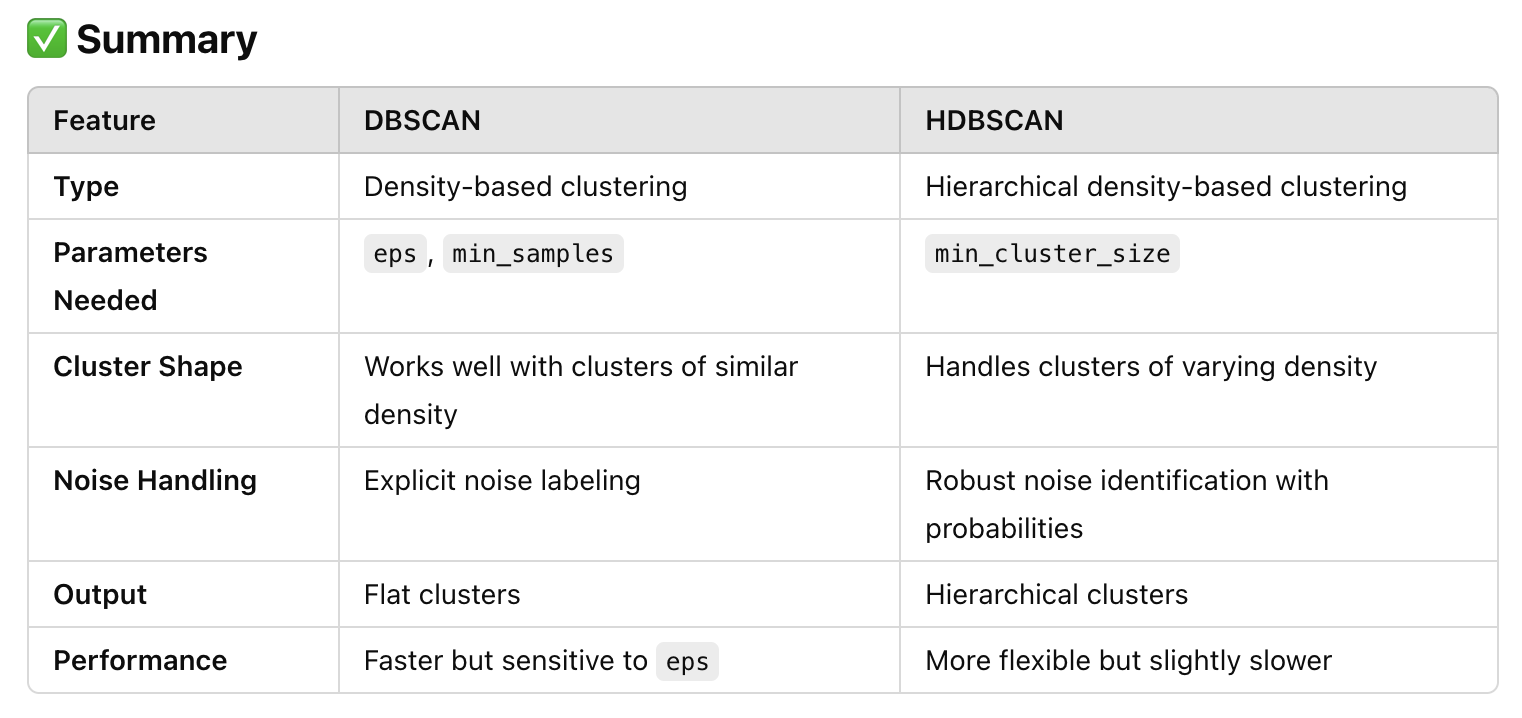

💡 When to Use Each  
Use DBSCAN if you know the expected density and want faster results.  
Use HDBSCAN if you have varying cluster densities or want fewer parameter tuning challenges.  

## 6.1 Run HDBSCAN Clustering
Key Parameters:

- min_cluster_size=20: Minimum number of points in a cluster.  
- min_samples=5: Minimum number of points to define a core point.  
- cluster_selection_epsilon=0.01: Controls cluster compactness (smaller values → tighter clusters).  
- gen_min_span_tree=True: Enables visualization of hierarchical clustering.

Parameter Tuning Tips:  
- Increase min_cluster_size to get larger clusters.
- Lower min_samples to detect more flexible clusters.
- Adjust cluster_selection_epsilon for tighter or looser clusters.

## 6.2 Visualize Clusters

In [18]:
# Initialize and fit HDBSCAN model
coords = np.array(list(zip(clipped_gdf_projected.geometry.x, clipped_gdf_projected.geometry.y)))
ncs = 25
ms = 6

# Ensure clipped_gdf is a copy to avoid SettingWithCopyWarning
clipped_gdf_projected = clipped_gdf_projected.copy()

# Initialize and fit HDBSCAN model
HDB_clusterer = hdbscan.HDBSCAN(
    min_cluster_size = ncs,
    min_samples = ms,
    # cluster_selection_epsilon=0.003,
    gen_min_span_tree=True 
)

# Assign clusters using .loc
clipped_gdf_projected.loc[:, "HDB_cluster"] = HDB_clusterer.fit_predict(coords)

# View cluster labels (-1 represents noise/outliers)
# print(clipped_gdf["HDB_cluster"].value_counts())
clipped_gdf_projected

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,img_name,year,month,day,hour,lat,lon,panoid,img_dir,exist,yolo_conf,yolo_bbox,yolo_num,prediction,Domestic,Construction,geometry,HDB_cluster
2130,fLCK5eRBG99LGbCuDSBlgQ_270,2018,2,NaN,NaN,-1.301553,37.068682,fLCK5eRBG99LGbCuDSBlgQ,Google/f/L/,True,[0.3712886571884155],"[[78.21759796142578, 205.15240478515625, 140.3...",1,yes,Y,Y,POINT (285106.759 9856056.789),-1
134,KQqt-j2iDREGChLobmRc6Q_270,2018,2,NaN,NaN,-1.267932,36.926420,KQqt-j2iDREGChLobmRc6Q,Google/K/Q/,True,[0.3236929476261139],"[[326.3240051269531, 168.91143798828125, 399.1...",1,yes,Y,N,POINT (269267.947 9859762.717),19
2550,J8QJYKLvKqLF8w4OoKfTuQ_270,2021,7,NaN,NaN,-1.290786,36.947096,J8QJYKLvKqLF8w4OoKfTuQ,Google/J/8/,True,[0.529024600982666],"[[322.16461181640625, 159.08607482910156, 400....",1,yes,Y,Y,POINT (271571.645 9857236.884),-1
758,MH78KhYMGe2dun78nwlT5w_270,2021,7,NaN,NaN,-1.287349,36.944651,MH78KhYMGe2dun78nwlT5w,Google/M/H/,True,[0.4912583529949188],"[[6.17279052734375, 158.3504638671875, 395.884...",1,yes,Y,Y,POINT (271299.152 9857616.775),-1
759,NWm1T8TxTt-Bmzi4rM72Nw_180,2021,8,NaN,NaN,-1.286800,36.950329,NWm1T8TxTt-Bmzi4rM72Nw,Google/N/W/,True,[0.34495213627815247],"[[306.3589172363281, 196.9697265625, 400.0, 25...",1,yes,Y,N,POINT (271931.178 9857678.067),8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2599,9PwIBuolh2emZsCd1sdLmg_270,2018,2,NaN,NaN,-1.172356,36.929183,9PwIBuolh2emZsCd1sdLmg,Google/9/P/,True,[0.4162435531616211],"[[255.76260375976562, 184.0593719482422, 366.9...",1,yes,Y,Y,POINT (269567.339 9870334.003),7
2933,Dqk-gB7bOQfUNTK60DoAHA_90,2018,2,NaN,NaN,-1.171336,36.926384,Dqk-gB7bOQfUNTK60DoAHA,Google/D/q/,True,"[0.47815805673599243, 0.2923596501350403]","[[181.90997314453125, 178.96670532226562, 374....",2,yes,Y,N,POINT (269255.722 9870446.639),7
3306,2RWOhtBYT4bIPRQN7N5e7Q_90,2018,2,NaN,NaN,-1.170963,36.926969,2RWOhtBYT4bIPRQN7N5e7Q,Google/2/R/,True,[0.30108121037483215],"[[279.8357849121094, 244.15794372558594, 399.0...",1,yes,Y,N,POINT (269320.781 9870487.958),7
3305,M2dwa7vqByWyEPpVI2I2kw_0,2018,2,NaN,NaN,-1.170780,36.928983,M2dwa7vqByWyEPpVI2I2kw,Google/M/2/,True,[0.6980969309806824],"[[95.78693389892578, 201.8352508544922, 397.75...",1,yes,Y,N,POINT (269544.958 9870508.318),7


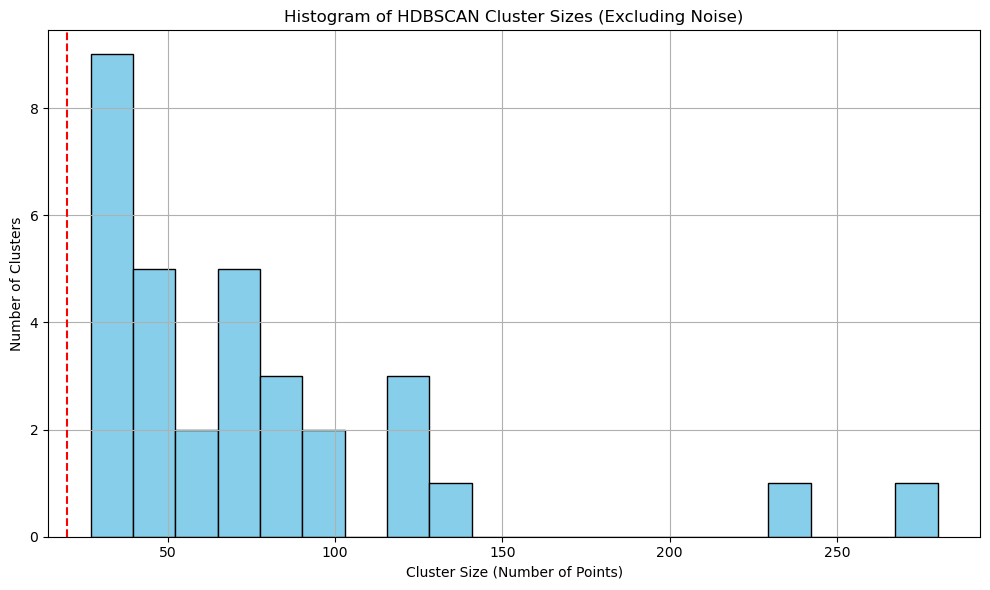

In [19]:
# Count points per cluster (including noise)
cluster_counts = clipped_gdf_projected["HDB_cluster"].value_counts()
# print(cluster_counts)

# Plot histogram (excluding noise if you prefer)
cluster_counts_no_noise = cluster_counts[cluster_counts.index != -1]

plt.figure(figsize=(10, 6))
plt.hist(cluster_counts_no_noise, bins=20, edgecolor='black', color='skyblue')
plt.title("Histogram of HDBSCAN Cluster Sizes (Excluding Noise)")
plt.xlabel("Cluster Size (Number of Points)")
plt.ylabel("Number of Clusters")
plt.axvline(20, color='red', linestyle='--', label='min_cluster_size')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Get persistence per cluster
persistence = HDB_clusterer.cluster_persistence_
print("Cluster persistences:", persistence)

Cluster persistences: [0.12547313 0.00543062 0.00302207 0.03109315 0.03429233 0.16935016
 0.13932154 0.16512356 0.01135582 0.32537008 0.05903311 0.11662897
 0.26404165 0.02813691 0.0955108  0.1697471  0.09732625 0.02741954
 0.17875028 0.10175164 0.13250661 0.05612651 0.06585872 0.0773537
 0.20915586 0.01799609 0.29164709 0.09611499 0.06233273 0.06455594
 0.06470493 0.33830076]


In [21]:
n_total = len(clipped_gdf_projected)
n_noise = (clipped_gdf_projected['HDB_cluster'] == -1).sum()
print(f"Noise points: {n_noise} / {n_total} ({n_noise/n_total:.2%})")

Noise points: 763 / 3236 (23.58%)


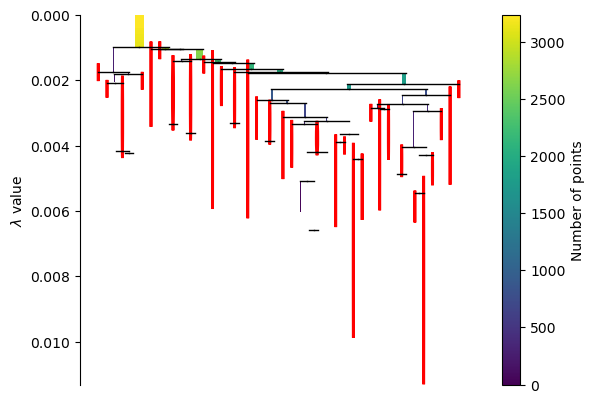

In [22]:
# Condensed tree
HDB_clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette('deep', 8))
plt.show()

This tells you:
- How the hierarchy of clusters was built
- Which clusters are "strong" and at what lambda level they split

In [23]:
mask = clipped_gdf_projected["HDB_cluster"] != -1
coords_valid = coords[mask]
labels_valid = clipped_gdf_projected.loc[mask, "HDB_cluster"]

if len(set(labels_valid)) > 1:
    score = silhouette_score(coords_valid, labels_valid)
    print(f"Silhouette score (excluding noise): {score:.3f}")
else:
    print("Too few clusters for silhouette score.")

Silhouette score (excluding noise): 0.484


## 6.3 Fine Tuning (Robusntess) 

In [26]:
# Prepare lists of parameters to try
min_cluster_sizes = [15, 20, 30, 40]
min_samples_list = [4, 6, 8, 10]

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                gen_min_span_tree=False
            )
            labels = clusterer.fit_predict(coords)
            
            # Calculate noise ratio
            noise_ratio = np.sum(labels == -1) / len(labels)
            
            # Number of clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            # Calculate average cluster persistence (if clusters found)
            if n_clusters > 0:
                persistence_avg = np.mean(clusterer.cluster_persistence_)
            else:
                persistence_avg = np.nan
            
            # Silhouette score calculation (exclude noise points)
            if n_clusters > 1:
                mask = labels != -1
                sil_score = silhouette_score(coords[mask], labels[mask])
            else:
                sil_score = np.nan
            
            results.append({
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "noise_ratio": noise_ratio,
                "n_clusters": n_clusters,
                "avg_persistence": persistence_avg,
                "silhouette_score": sil_score
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort results by silhouette score descending (best clustering first)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

results_df

,min_cluster_size,min_samples,noise_ratio,n_clusters,avg_persistence,silhouette_score
7,20,10,0.279357,31,0.098964,0.511670
6,20,8,0.248146,33,0.106178,0.497779
10,30,8,0.268232,24,0.122376,0.492878
14,40,8,0.278739,23,0.138622,0.491297
3,15,10,0.234549,43,0.040976,0.490490
1,15,6,0.205810,59,0.036887,0.489680
15,40,10,0.290482,22,0.134024,0.483117
5,20,6,0.199629,42,0.094499,0.480039
11,30,10,0.300062,23,0.130170,0.479571
2,15,8,0.217553,47,0.032872,0.476207


## 6.4 Optional: Cluster Probability & Stability
HDBSCAN provides additional insights:  
- Probability: Likelihood that each point belongs to its assigned cluster.
- Stability: Stability of each cluster (higher is better).

In [27]:
# Get the cluster labels for each point
labels = HDB_clusterer.labels_

clipped_gdf_projected["probability"] = HDB_clusterer.probabilities_

# Create a mapping from cluster label to its stability value (skip noise label -1)
# Ensure you only consider non-noise clusters
valid_clusters = [label for label in np.unique(labels) if label != -1]
stability_values = HDB_clusterer.cluster_persistence_

# Create a dictionary: cluster label -> stability
stability_dict = {label: stability for label, stability in zip(valid_clusters, stability_values)}

# Map each point's label to its stability value; assign NaN for noise points (-1)
clipped_gdf_projected['stability'] = clipped_gdf_projected['HDB_cluster'].apply(lambda x: stability_dict.get(x, np.nan))
# clipped_gdf
print(clipped_gdf_projected[["HDB_cluster", "probability", "stability"]].head())

      HDB_cluster  probability  stability
2130           -1     0.000000        NaN
134            19     0.714112   0.101752
2550           -1     0.000000        NaN
758            -1     0.000000        NaN
759             8     0.981863   0.011356


In [28]:
# High-confidence core points in stable clusters
core_points = clipped_gdf_projected[(clipped_gdf_projected["probability"] > 0.9) & (clipped_gdf_projected["stability"] > 0.1)]

# Low-stability clusters
weak_clusters = clipped_gdf_projected[(clipped_gdf_projected["stability"] < 0.05) & (clipped_gdf_projected["HDB_cluster"] != -1)]

# Visualize or summarize noise
noise_points = clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] == -1]

In [29]:
# ----------- Quantify Clusters -----------

# Total number of clusters (excluding noise)
n_clusters = clipped_gdf_projected["HDB_cluster"].nunique() - (1 if -1 in clipped_gdf_projected["HDB_cluster"].unique() else 0)

# Noise percentage
noise_ratio = (clipped_gdf_projected["HDB_cluster"] == -1).sum() / len(clipped_gdf_projected)

print(f"Number of clusters: {n_clusters}")
print(f"Noise percentage: {noise_ratio:.2%}")

Number of clusters: 32
Noise percentage: 23.58%


In [30]:
# ----------- Examine Cluster Properties -----------
cluster_summary = (
    clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] != -1]
    .groupby("HDB_cluster")
    .agg(
        n_points=("HDB_cluster", "count"),
        mean_prob=("probability", "mean"),
        min_prob=("probability", "min"),
        max_prob=("probability", "max"),
        stability=("stability", "first")  # all points in a cluster have same stability
    )
    .sort_values("stability", ascending=False)
)

print(cluster_summary.head())

             n_points  mean_prob  min_prob  max_prob  stability
HDB_cluster                                                    
31                 63   0.844940  0.521767       1.0   0.338301
9                  43   0.901131  0.289159       1.0   0.325370
26                 65   0.805083  0.470260       1.0   0.291647
12                 99   0.793533  0.342928       1.0   0.264042
24                 31   0.982503  0.666863       1.0   0.209156


In [31]:
# ----------- Filter & Categorize Clusters ----------- 

# Example thresholds (adjust if needed)
stability_threshold = 0.1
prob_threshold = 0.9

clipped_gdf_projected["cluster_quality"] = clipped_gdf_projected.apply(
    lambda row: (
        "Noise" if row["HDB_cluster"] == -1 else
        "Strong" if (row["stability"] > stability_threshold and row["probability"] > prob_threshold)
        else "Weak"
    ),
    axis=1
)

print(clipped_gdf_projected["cluster_quality"].value_counts())

cluster_quality
Weak      1681
Strong     792
Noise      763
Name: count, dtype: int64


Text(0.5, 1.0, 'Fly-Tipping Clusters by Quality')

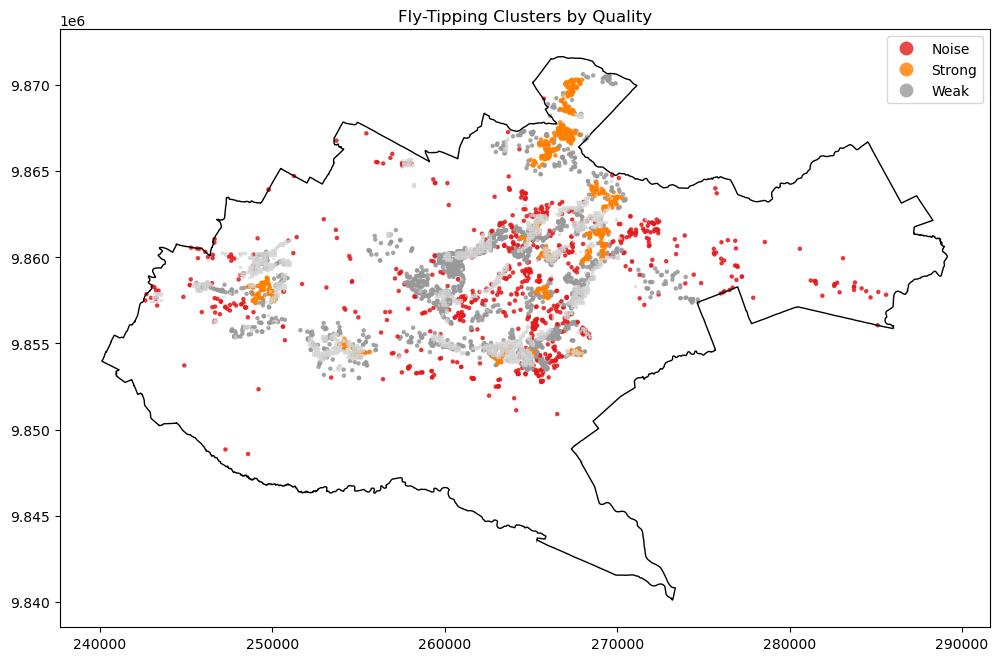

In [32]:
fig, ax = plt.subplots(figsize=(12, 12))
clipped_gdf_projected.plot(column="cluster_quality", ax=ax, legend=True, cmap="Set1", markersize=5, alpha=0.8)
boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
slums_gdf_projected.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Clusters by Quality")

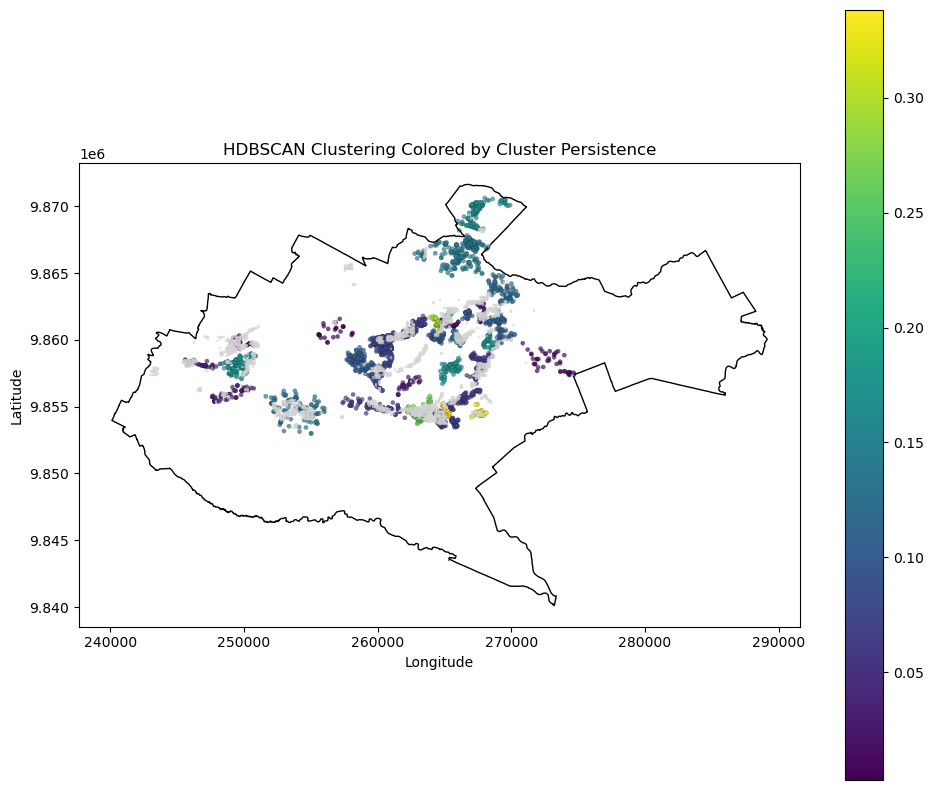

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters colored by persistence
clipped_gdf_projected.plot(
    ax=ax,
    column='stability',
    cmap='viridis',         # Change color map if preferred
    legend=True,
    markersize=10,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.1
)

boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
slums_gdf_projected.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

# Title and labels
ax.set_title("HDBSCAN Clustering Colored by Cluster Persistence")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Calculate summary stats
n_clusters = clipped_gdf_projected["HDB_cluster"].nunique() - (1 if -1 in clipped_gdf_projected["HDB_cluster"].unique() else 0)
noise_ratio = (clipped_gdf_projected["HDB_cluster"] == -1).sum() / len(clipped_gdf_projected)

# # Annotation text box
# param_text = (
#     "HDBSCAN Parameters:\n"
#     "min_cluster_size = 30\n"
#     "min_samples = 8\n"
#     f"Detected clusters = {n_clusters}\n"
#     f"Noise ratio ≈ {noise_ratio:.2%}"
# )
# ax.text(
#     0.01, 0.99,
#     param_text,
#     transform=ax.transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
# )

plt.tight_layout()
plt.savefig("HDBSCAN_Persistence_Map.png", dpi=300, bbox_inches='tight')
plt.show()

| Column                    | Meaning                                                              |
| ------------------------- | -------------------------------------------------------------------- |
| `cluster` / `HDB_cluster` | The assigned cluster label for each point (`-1` = noise)             |
| `probability`             | HDBSCAN soft clustering confidence (0–1), how likely a point belongs |
| `cluster_quality`         | Often derived from stability, combines size and persistence          |
| `distance_to_slum`        | Your own variable (not part of HDBSCAN)                              |
| `centroid`                | Likely centroid of each cluster                                      |
| `HDB_distance_to_slum`    | Possibly average slum distance per cluster                           |
| `Gi*`, `p_value`          | From hot spot analysis / spatial stats, not from HDBSCAN             |


In [34]:
cluster_stats = (
    clipped_gdf_projected[clipped_gdf_projected["HDB_cluster"] != -1]
    .groupby("HDB_cluster")["geometry"]
    .apply(lambda x: MultiPoint(list(x)).convex_hull)
    .to_frame(name="geometry")
)

cluster_stats["area_m2"] = cluster_stats.geometry.area
cluster_stats["n_points"] = clipped_gdf_projected.groupby("HDB_cluster").size()
cluster_stats["density_per_km2"] = cluster_stats["n_points"] / (cluster_stats["area_m2"] / 1e6)

print(cluster_stats[["n_points", "area_m2", "density_per_km2"]].sort_values("density_per_km2", ascending=False))

             n_points       area_m2  density_per_km2
HDB_cluster                                         
24                 31  9.560585e+04       324.247940
31                 63  2.416486e+05       260.709146
30                 34  2.387977e+05       142.379918
26                 65  4.882330e+05       133.133166
29                 72  6.359793e+05       113.211226
14                 27  2.618561e+05       103.110080
27                 57  6.658216e+05        85.608522
20                 49  5.955127e+05        82.282046
18                 50  6.536366e+05        76.495102
9                  43  5.695981e+05        75.491821
25                 33  4.430273e+05        74.487504
28                 90  1.324476e+06        67.951404
22                 88  1.367597e+06        64.346447
17                 35  5.831552e+05        60.018332
16                129  2.530617e+06        50.975706
23                280  5.837275e+06        47.967588
5                 125  2.706106e+06        46.

## Save Result 

In [42]:
# clipped_gdf.to_file("fly_tipping_clusters.geojson", driver="GeoJSON")

## Match with informal settlements

In [47]:
# # Spatial Join: Points Inside Informal Settlements
# points_in_informal = gpd.sjoin(clipped_gdf_projected, slums_gdf_projected, how='inner', predicate='within')

# # Cluster Counts Within Informal Settlements
# counts_per_cluster = points_in_informal['HDB_cluster'].value_counts()

# # Proportion of Each Cluster Inside Informal Settlements
# all_counts = clipped_gdf_projected['HDB_cluster'].value_counts()
# prop_in_informal = (counts_per_cluster / all_counts).fillna(0)

In [48]:
# # (Optional) Clusters Near Informal Settlements

# buffered_informal = slums_gdf_projected.buffer(50)  # 50 meters as an example
# buffered_gdf = gpd.GeoDataFrame(geometry=buffered_informal, crs=slums_gdf_projected.crs)
# nearby_points = gpd.sjoin(clipped_gdf_projected, buffered_gdf, how='inner', predicate='intersects')

In [49]:
# # Calculate distance from each point to informal settlements (slums_gdf)
# clipped_gdf_projected['distance_to_slum'] = clipped_gdf_projected.geometry.apply(lambda point: slums_gdf_projected.distance(point).min())

# # Summary statistics
# print(clipped_gdf_projected['distance_to_slum'].describe())

count     3236.000000
mean       517.459899
std        938.219194
min          0.000000
25%         28.070980
50%        248.053898
75%        627.158925
max      11010.195258
Name: distance_to_slum, dtype: float64


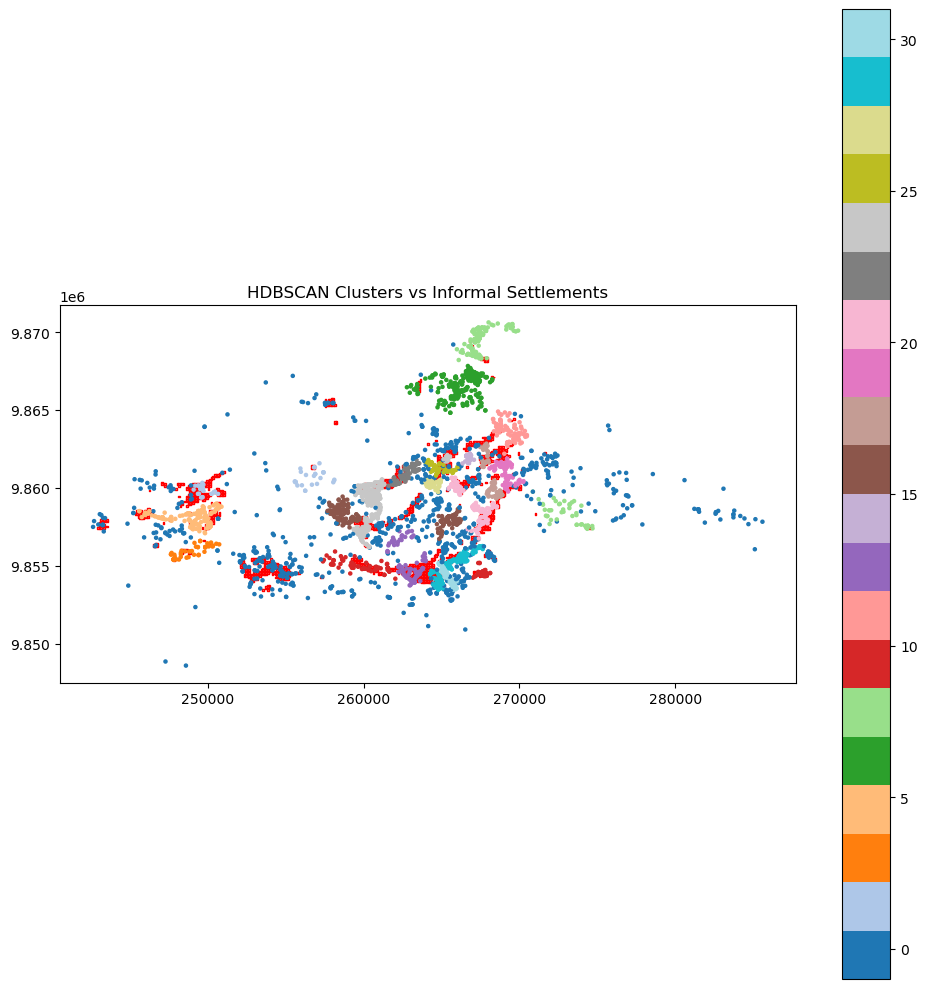

In [50]:
# fig, ax = plt.subplots(figsize=(10, 10))
# slums_gdf_projected.plot(ax=ax, facecolor='none', edgecolor='red', label='Informal Areas')
# clipped_gdf_projected.plot(ax=ax, column='HDB_cluster', cmap='tab20', markersize=5, legend=True)

# plt.title("HDBSCAN Clusters vs Informal Settlements")
# # plt.legend()
# plt.tight_layout()
# plt.show()

| Metric               | Description                                                              | Interpretation                                                                                                          |
| -------------------- | ------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------- |
| `counts_per_cluster` | Number of points per cluster that fall **within** informal settlements   | Indicates which clusters are **spatially embedded** in informal areas                                                   |
| `prop_in_informal`   | Proportion of each cluster's points that are within informal settlements | Tells you how **informal-focused** a cluster is — values near 1 mean **entirely informal**, near 0 means mostly outside |
| `all_counts`         | Total size of each cluster                                               | Helps you **normalize** comparisons (e.g. to see if large clusters are disproportionately informal)                     |


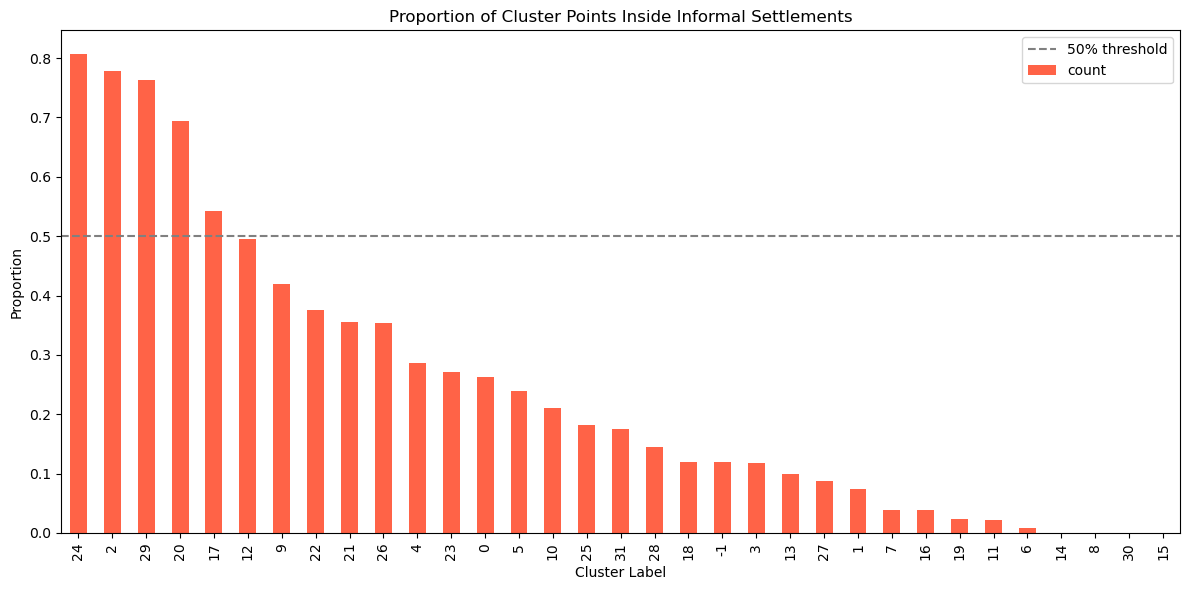

In [51]:
# # import matplotlib.pyplot as plt
# %matplotlib inline

# # Sort by proportion
# sorted_prop = prop_in_informal.sort_values(ascending=False)

# plt.figure(figsize=(12, 6))
# sorted_prop.plot(kind='bar', color='tomato')
# plt.title("Proportion of Cluster Points Inside Informal Settlements")
# plt.ylabel("Proportion")
# plt.xlabel("Cluster Label")
# plt.axhline(0.5, color='gray', linestyle='--', label='50% threshold')
# plt.legend()
# plt.tight_layout()
# plt.show()

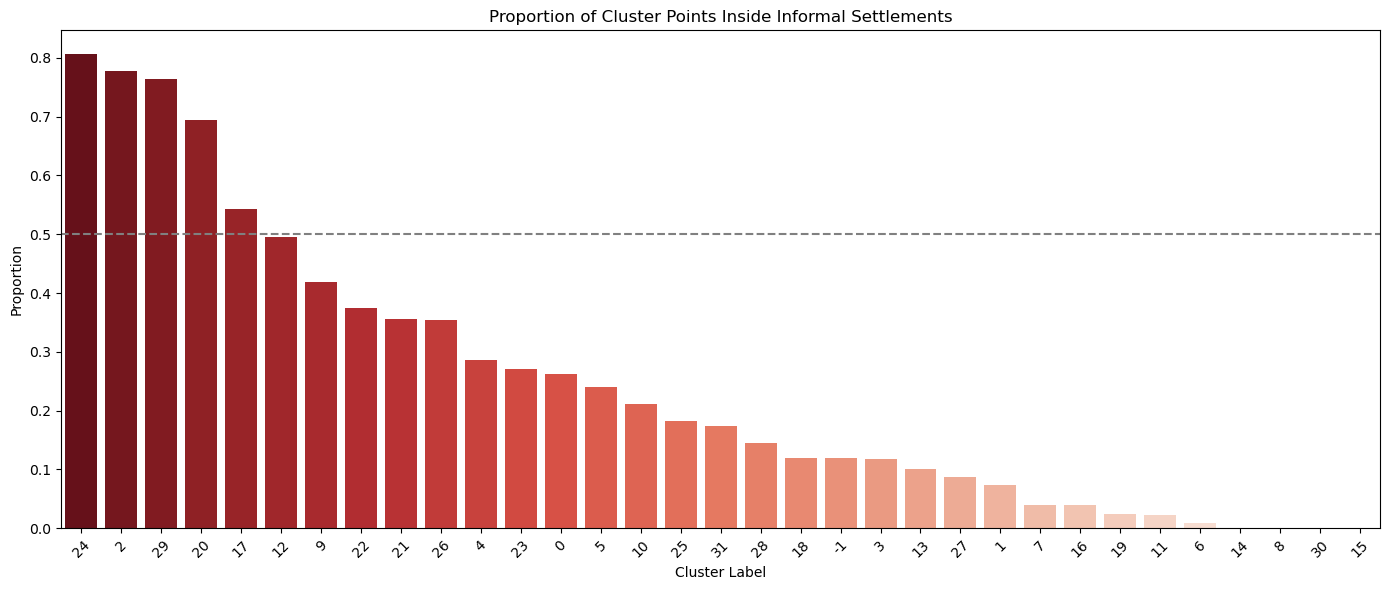

In [52]:
# # Make sure prop_in_informal is a Series
# sorted_prop = prop_in_informal.sort_values(ascending=False)

# # Convert to DataFrame for Seaborn
# df = pd.DataFrame({
#     'Cluster': sorted_prop.index.astype(str),
#     'Proportion': sorted_prop.values
# })

# # Plot
# plt.figure(figsize=(14, 6))
# sns.barplot(
#     data=df,
#     x='Cluster',
#     y='Proportion',
#     hue='Cluster',          # assign hue
#     palette='Reds_r',
#     dodge=False,            # keep bars single (no grouping)
#     legend=False            # remove redundant legend
# )

# plt.axhline(0.5, color='gray', linestyle='--', label='50% threshold')

# plt.title("Proportion of Cluster Points Inside Informal Settlements")
# plt.ylabel("Proportion")
# plt.xlabel("Cluster Label")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

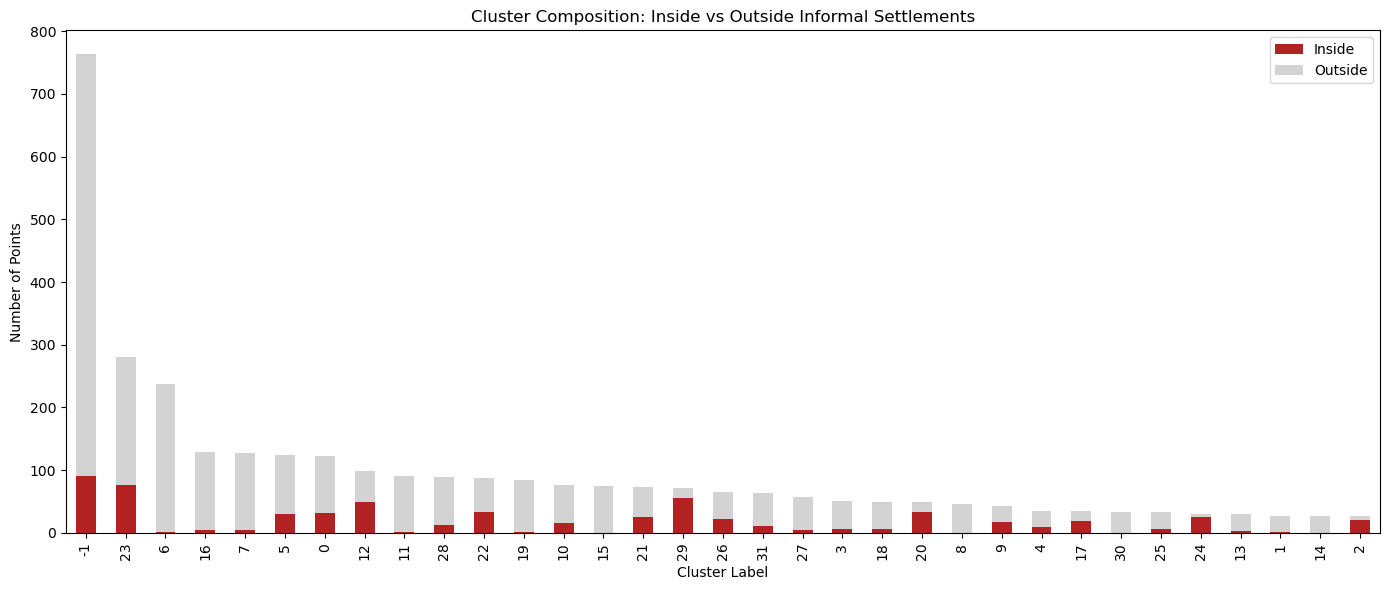

In [53]:
# inside = counts_per_cluster.reindex(all_counts.index).fillna(0)
# outside = all_counts - inside

# df_stack = pd.DataFrame({'Inside': inside, 'Outside': outside})

# df_stack.plot(kind='bar', stacked=True, figsize=(14,6), color=['firebrick', 'lightgray'])
# plt.title("Cluster Composition: Inside vs Outside Informal Settlements")
# plt.ylabel("Number of Points")
# plt.xlabel("Cluster Label")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [54]:
# # Exclude noise from total cluster counts
# all_counts = clipped_gdf_projected[clipped_gdf_projected['HDB_cluster'] != -1]['HDB_cluster'].value_counts()

# # Count how many cluster points are within informal settlements
# counts_per_cluster = points_in_informal['HDB_cluster'].value_counts()

# # Compute the proportion
# prop_in_informal = (counts_per_cluster / all_counts).fillna(0).sort_index()
# prop_in_informal

HDB_cluster
-1     0.000000
 0     0.262295
 1     0.074074
 2     0.777778
 3     0.117647
 4     0.285714
 5     0.240000
 6     0.008439
 7     0.039062
 8     0.000000
 9     0.418605
 10    0.210526
 11    0.021978
 12    0.494949
 13    0.100000
 14    0.000000
 15    0.000000
 16    0.038760
 17    0.542857
 18    0.120000
 19    0.023529
 20    0.693878
 21    0.356164
 22    0.375000
 23    0.271429
 24    0.806452
 25    0.181818
 26    0.353846
 27    0.087719
 28    0.144444
 29    0.763889
 30    0.000000
 31    0.174603
Name: count, dtype: float64

##  Distance-Based Metrics

In [55]:
# # Calculate centroid of each cluster
# clipped_gdf_projected["centroid"] = clipped_gdf_projected.groupby("HDB_cluster")["geometry"].transform(lambda x: MultiPoint(x.tolist()).centroid)

# # Compute minimum distance to slum boundary
# clipped_gdf_projected["HDB_distance_to_slum"] = clipped_gdf_projected["centroid"].apply(lambda x: slums_gdf_projected.distance(x).min())

# # Average distance
# print("Average distance to slum boundary (m):", clipped_gdf_projected["HDB_distance_to_slum"].mean())

# # Proportion within 500m buffer
# within_500m = clipped_gdf_projected[clipped_gdf_projected["HDB_distance_to_slum"] <= 500]
# print("Proportion of clusters within 500m of slums:", len(within_500m) / len(clipped_gdf_projected))

# # Proportion within 2km buffer
# within_2000m = clipped_gdf_projected[clipped_gdf_projected["HDB_distance_to_slum"] <= 2000]
# print("Proportion of clusters within 2km of slums:", len(within_2000m) / len(clipped_gdf_projected))

Average distance to slum boundary (m): 478.934157957836
Proportion of clusters within 500m of slums: 0.7444375772558715
Proportion of clusters within 2km of slums: 0.926761433868974


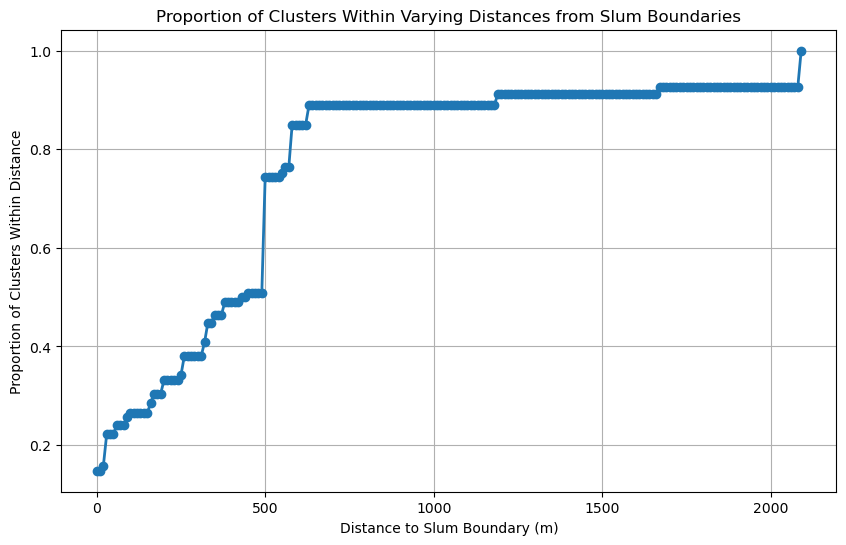

In [56]:
# # Simulated data: distance from cluster centroid to slum boundary (in meters)
# np.random.seed(42)

# # Range of buffer distances (100m to 2000m in steps of 100m)
# buffer_distances = np.arange(0, 2100, 10)
# proportions_within_distance = []

# # Calculate proportion within each buffer distance
# for distance in buffer_distances:
#     proportion = (clipped_gdf_projected["HDB_distance_to_slum"] <= distance).mean()
#     proportions_within_distance.append(proportion)

# # Plot results
# plt.figure(figsize=(10, 6))
# plt.plot(buffer_distances, proportions_within_distance, marker='o', linestyle='-', linewidth=2)
# plt.xlabel("Distance to Slum Boundary (m)")
# plt.ylabel("Proportion of Clusters Within Distance")
# plt.title("Proportion of Clusters Within Varying Distances from Slum Boundaries")
# plt.grid(True)
# plt.show()

# Hotspot Analysis (Getis-Ord Gi)* 这个不对-不应该用cluster

In [57]:
# # Check all column data types
# print(clipped_gdf_projected.dtypes)

# # Check a specific column type
# print(clipped_gdf_projected["HDB_distance_to_slum"].dtype)

img_name                  object
year                       int64
month                      int64
day                      float64
hour                     float64
lat                      float64
lon                      float64
panoid                    object
img_dir                   object
exist                       bool
yolo_conf                 object
yolo_bbox                 object
yolo_num                   int64
prediction                object
Domestic                  object
Construction              object
geometry                geometry
HDB_cluster                int64
probability              float64
stability                float64
cluster_quality           object
distance_to_slum         float64
centroid                geometry
HDB_distance_to_slum     float64
dtype: object
float64


<Axes: title={'center': 'HDBSCAN Clusters vs Informal Settlements'}>

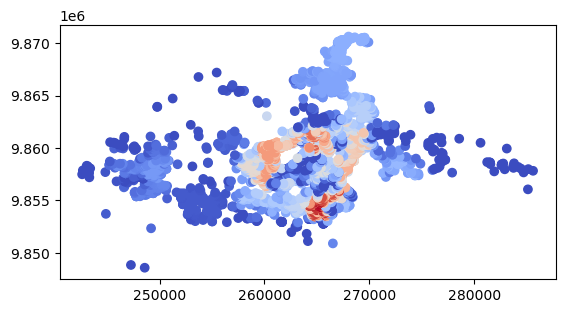

In [58]:
# # Convert cluster column to float
# clipped_gdf_projected["HDB_cluster"] = clipped_gdf_projected["HDB_cluster"].astype(float)

# # Create spatial weight matrix
# w = Queen.from_dataframe(clipped_gdf_projected, use_index=False)
# w.transform = "R"

# # Calculate Gi*
# gi_star = G_Local(clipped_gdf_projected["HDB_cluster"], w)

# # Add to GeoDataFrame
# clipped_gdf_projected["Gi*"] = gi_star.Zs

# clipped_gdf_projected.plot(column="Gi*", cmap="coolwarm", legend=False)
# boundary_projected.plot(ax=ax, color='black', edgecolor='black', linewidth=1, label="Boundary")
# # slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

In [59]:
# # Display Gi* Z-scores and their significance
# print(clipped_gdf_projected[["Gi*"]].describe())  # Summary stats
# print(clipped_gdf_projected.sort_values("Gi*", ascending=False).head())  # Top hotspots

               Gi*
count  3236.000000
mean     -0.007026
std       0.880021
min      -1.181663
25%      -0.726507
50%      -0.143719
75%       0.738379
max       1.891196
                        img_name  year  month  day  hour       lat        lon  \
3732  VusOg-Qr2k4cZgPJtInivg_180  2021      8  NaN   NaN -1.316705  36.890257   
3740    VusOg-Qr2k4cZgPJtInivg_0  2021      8  NaN   NaN -1.316705  36.890257   
3735    vsfyosDL50T8xxX5_28G1g_0  2021      8  NaN   NaN -1.315852  36.889705   
3672  wf_ReXgnHb6UAPd9e0VMVA_180  2021      8  NaN   NaN -1.315002  36.889172   
3671  Zuijd7LolF1XTTRr68L8Nw_180  2021      8  NaN   NaN -1.315382  36.889423   

                      panoid      img_dir  exist  ... Construction  \
3732  VusOg-Qr2k4cZgPJtInivg  Google/V/u/   True  ...            Y   
3740  VusOg-Qr2k4cZgPJtInivg  Google/V/u/   True  ...            N   
3735  vsfyosDL50T8xxX5_28G1g  Google/v/s/   True  ...            Y   
3672  wf_ReXgnHb6UAPd9e0VMVA  Google/w/f/   True  ...         

In [60]:
# # Get significant hotspots (95% confidence)
# hotspots = clipped_gdf_projected[clipped_gdf_projected["Gi*"] > 1.96]
# coldspots = clipped_gdf_projected[clipped_gdf_projected["Gi*"] < -1.96]

# print(f"Hotspots count: {len(hotspots)}")
# print(f"Coldspots count: {len(coldspots)}")

Hotspots count: 0
Coldspots count: 0


/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_58829/46002155.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_58829/46002155.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


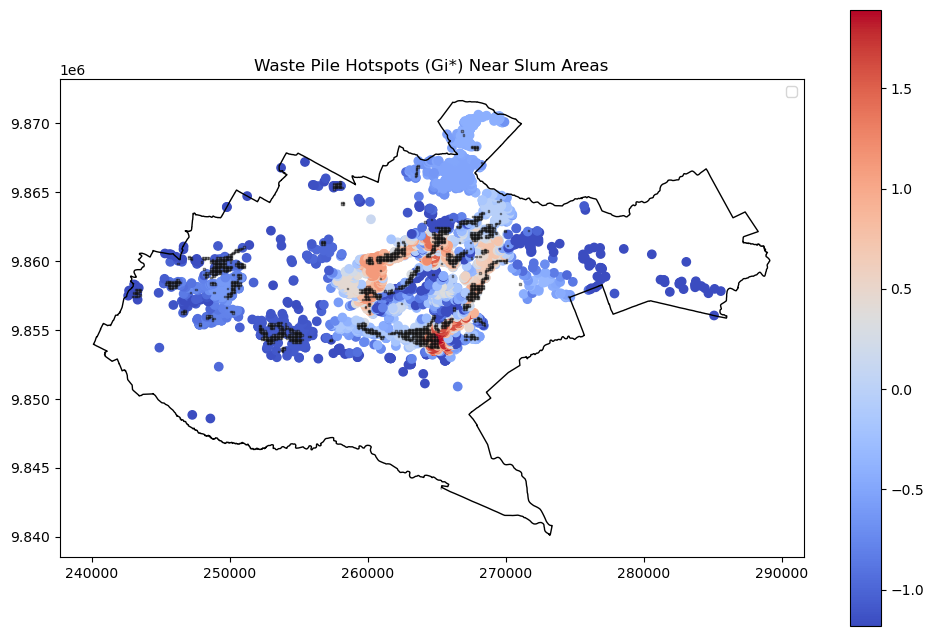

In [61]:
# ax = clipped_gdf_projected.plot(column="Gi*", cmap="coolwarm", legend=True, figsize=(12, 8))
# slums_gdf_projected.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5, label="Slums")
# boundary_projected.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")

# plt.title("Waste Pile Hotspots (Gi*) Near Slum Areas")
# plt.legend()
# plt.show()

In [62]:
# # Spatial join to find hotspots within slums
# hotspots_in_slums = gpd.sjoin(hotspots, slums_gdf, how="inner")
# print(f"Hotspots overlapping slums: {len(hotspots_in_slums)}")

Hotspots overlapping slums: 0


/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_58829/2518416964.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:32737
Right CRS: EPSG:4326

  hotspots_in_slums = gpd.sjoin(hotspots, slums_gdf, how="inner")


In [63]:
# # Add p-values to GeoDataFrame (from Gi* object)
# clipped_gdf["p_value"] = gi_star.p_sim  # Assuming gi_star is your G_Local object
# significant = clipped_gdf[clipped_gdf["p_value"] < 0.05]

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
